Imports

In [3]:
import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix

Load Data

In [4]:
df = pd.read_csv('News_Final.csv')
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (93239, 11)


,IDLink,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn
0,99248.0,Obama Lays Wreath at Arlington National Cemetery,Obama Lays Wreath at Arlington National Cemete...,USA TODAY,obama,2002-04-02 00:00:00,0.000000,-0.053300,-1,-1,-1
1,10423.0,A Look at the Health of the Chinese Economy,"Tim Haywood, investment director business-unit...",Bloomberg,economy,2008-09-20 00:00:00,0.208333,-0.156386,-1,-1,-1
2,18828.0,Nouriel Roubini: Global Economy Not Back to 2008,"Nouriel Roubini, NYU professor and chairman at...",Bloomberg,economy,2012-01-28 00:00:00,-0.425210,0.139754,-1,-1,-1
3,27788.0,Finland GDP Expands In Q4,Finland's economy expanded marginally in the t...,RTT News,economy,2015-03-01 00:06:00,0.000000,0.026064,-1,-1,-1
4,27789.0,"Tourism, govt spending buoys Thai economy in J...",Tourism and public spending continued to boost...,The Nation - Thailand&#39;s English news,economy,2015-03-01 00:11:00,0.000000,0.141084,-1,-1,-1


Basic EDA

In [6]:
print("Column types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTopic distribution:")
print(df['Topic'].value_counts())

Column types:
 IDLink               float64
Title                 object
Headline              object
Source                object
Topic                 object
PublishDate           object
SentimentTitle       float64
SentimentHeadline    float64
Facebook               int64
GooglePlus             int64
LinkedIn               int64
dtype: object

Missing values:
 IDLink                 0
Title                  0
Headline              15
Source               279
Topic                  0
PublishDate            0
SentimentTitle         0
SentimentHeadline      0
Facebook               0
GooglePlus             0
LinkedIn               0
dtype: int64

Topic distribution:
Topic
economy      33928
obama        28610
microsoft    21858
palestine     8843
Name: count, dtype: int64


Share Count Distribution

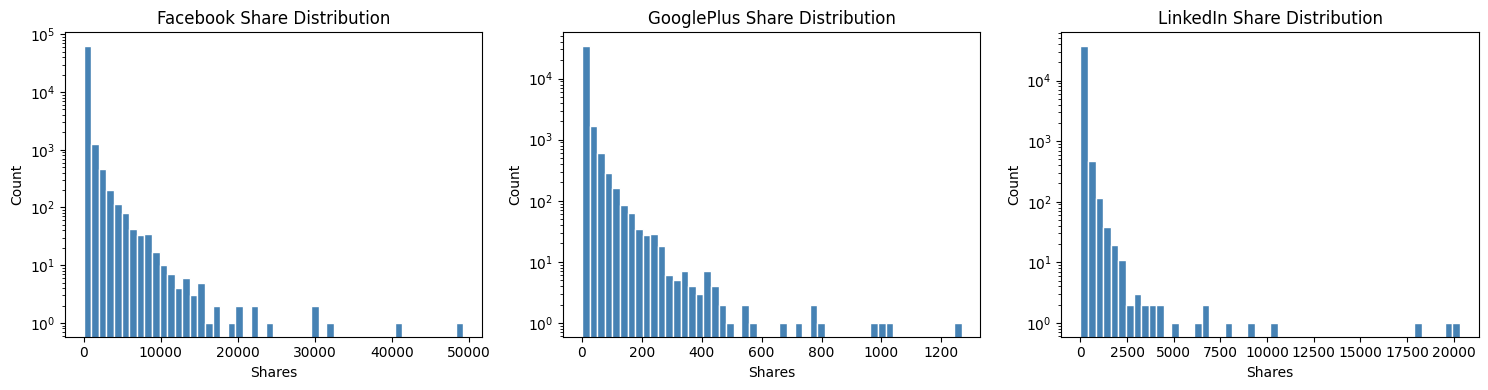

Saved share_distributions.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
platforms = ['Facebook', 'GooglePlus', 'LinkedIn']

for ax, col in zip(axes, platforms):
    valid = df[df[col] > 0][col]
    ax.hist(valid, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} Share Distribution')
    ax.set_xlabel('Shares')
    ax.set_ylabel('Count')
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('share_distributions.png', dpi=150)
plt.show()
print("Saved share_distributions.png")

Clean Data

In [8]:
df['Title']    = df['Title'].fillna('')
df['Headline'] = df['Headline'].fillna('')
df['Topic']    = df['Topic'].fillna('unknown')
df['text']     = df['Title'] + ' ' + df['Headline']

# Remove rows where ALL platforms are -1
df = df[~((df['Facebook'] == -1) & (df['GooglePlus'] == -1) & (df['LinkedIn'] == -1))]
print(f"After cleaning: {df.shape}")

After cleaning: (87495, 12)


Sentiment Analysis EDA

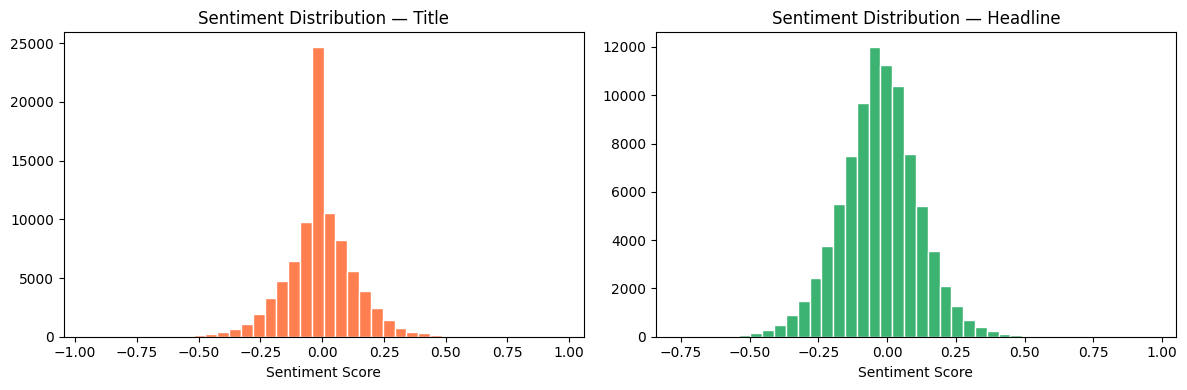

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SentimentTitle'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Sentiment Distribution — Title')
axes[0].set_xlabel('Sentiment Score')

axes[1].hist(df['SentimentHeadline'], bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Sentiment Distribution — Headline')
axes[1].set_xlabel('Sentiment Score')

plt.tight_layout()
plt.savefig('sentiment_distributions.png', dpi=150)
plt.show()

Platform Comparison EDA

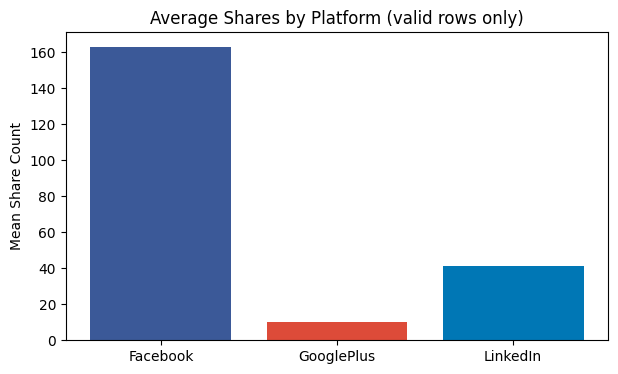

{'Facebook': np.float64(162.99271526245118), 'GooglePlus': np.float64(9.96997834325934), 'LinkedIn': np.float64(41.14399574920298)}


In [10]:
platform_means = {}
for col in ['Facebook', 'GooglePlus', 'LinkedIn']:
    valid = df[df[col] > 0][col]
    platform_means[col] = valid.mean()

plt.figure(figsize=(7, 4))
plt.bar(platform_means.keys(), platform_means.values(),
        color=['#3b5998', '#dd4b39', '#0077b5'])
plt.title('Average Shares by Platform (valid rows only)')
plt.ylabel('Mean Share Count')
plt.savefig('platform_comparison.png', dpi=150)
plt.show()
print(platform_means)

Structural Feature Engineering

In [11]:
def build_structural_features(df):
    feats = pd.DataFrame()
    feats['title_len']          = df['Title'].str.len()
    feats['title_words']        = df['Title'].str.split().str.len()
    feats['headline_words']     = df['Headline'].str.split().str.len()
    feats['exclamation']        = df['Title'].str.count('!')
    feats['question']           = df['Title'].str.count(r'\?')
    feats['caps_ratio']         = df['Title'].apply(
                                    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    feats['num_count']          = df['Title'].str.count(r'\d')
    feats['colon_present']      = df['Title'].str.contains(':').astype(int)
    feats['quote_present']      = df['Title'].str.contains('"').astype(int)
    feats['sentiment_title']    = df['SentimentTitle']
    feats['sentiment_headline'] = df['SentimentHeadline']
    feats['sentiment_diff']     = (df['SentimentTitle'] - df['SentimentHeadline']).abs()

    topic_dummies = pd.get_dummies(df['Topic'], prefix='topic')
    feats = pd.concat([feats.reset_index(drop=True),
                       topic_dummies.reset_index(drop=True)], axis=1)

    # Force all to numeric
    feats = feats.apply(pd.to_numeric, errors='coerce').fillna(0)
    return feats

struct = build_structural_features(df)
print(f"Structural features shape: {struct.shape}")
struct.head()

Structural features shape: (87495, 16)


,title_len,title_words,headline_words,exclamation,question,caps_ratio,num_count,colon_present,quote_present,sentiment_title,sentiment_headline,sentiment_diff,topic_economy,topic_microsoft,topic_obama,topic_palestine
0,19,4,28,0,0,0.105263,6,0,0,0.000000,-0.005906,0.005906,False,False,False,True
1,19,4,29,0,0,0.105263,6,0,0,0.000000,0.048546,0.048546,False,False,False,True
2,19,4,29,0,0,0.105263,5,0,0,-0.243068,0.048546,0.291614,False,False,False,True
3,79,14,66,0,0,0.063291,4,0,0,0.000000,-0.132812,0.132812,False,True,False,False
4,62,11,60,0,0,0.032258,1,1,0,-0.082022,0.205537,0.287559,True,False,False,False


TF-IDF Vectorization

In [12]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=3)
tfidf_matrix = tfidf.fit_transform(df['text'])
print(f"TF-IDF matrix: {tfidf_matrix.shape}")

TF-IDF matrix: (87495, 3000)


Combine Features

In [13]:
X = hstack([tfidf_matrix, csr_matrix(struct.values.astype(np.float32))])
print(f"Full feature matrix: {X.shape}")

Full feature matrix: (87495, 3016)


Label Creation Function

In [14]:
def make_label(series, threshold_pct=75):
    """Top 25% sharers on each platform = viral (1)"""
    valid = series[series >= 0]
    threshold = np.percentile(valid, threshold_pct)
    return (series >= threshold).astype(int), threshold

# Preview thresholds
for col in ['Facebook', 'GooglePlus', 'LinkedIn']:
    valid = df[df[col] >= 0][col]
    thresh = np.percentile(valid, 75)
    print(f"{col:12s} → 75th percentile threshold: {thresh:.0f} shares")

Facebook     → 75th percentile threshold: 44 shares
GooglePlus   → 75th percentile threshold: 2 shares
LinkedIn     → 75th percentile threshold: 4 shares


Train Facebook Model

In [16]:
col  = 'Facebook'
mask = (df[col] >= 0).values  # ← .values converts pandas Series to numpy array
X_plat = X[mask]
y, thresh = make_label(df.loc[df[col] >= 0, col])

print(f"Rows: {mask.sum()} | Threshold: {thresh:.0f} shares | Viral rate: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(
    X_plat, y, test_size=0.2, random_state=42, stratify=y)

fb_model = GradientBoostingClassifier(
    n_estimators=150, max_depth=4,
    learning_rate=0.1, subsample=0.8, random_state=42)

fb_model.fit(X_train, y_train)

y_prob = fb_model.predict_proba(X_test)[:, 1]
y_pred = fb_model.predict(X_test)
print(f"\nFacebook AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=['Not Viral', 'Viral']))

Rows: 81637 | Threshold: 44 shares | Viral rate: 25.11%

Facebook AUC-ROC: 0.7889
              precision    recall  f1-score   support

   Not Viral       0.83      0.91      0.87     12229
       Viral       0.64      0.44      0.52      4099

    accuracy                           0.80     16328
   macro avg       0.73      0.68      0.70     16328
weighted avg       0.78      0.80      0.78     16328



Train LinkedIn Model

In [18]:
col  = 'LinkedIn'
mask = (df[col] >= 0).values
X_plat = X[mask]
y, thresh = make_label(df.loc[df[col] >= 0, col])

print(f"Rows: {mask.sum()} | Threshold: {thresh:.0f} shares | Viral rate: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(
    X_plat, y, test_size=0.2, random_state=42, stratify=y)

li_model = GradientBoostingClassifier(
    n_estimators=150, max_depth=4,
    learning_rate=0.1, subsample=0.8, random_state=42)

li_model.fit(X_train, y_train)

y_prob = li_model.predict_proba(X_test)[:, 1]
y_pred = li_model.predict(X_test)
print(f"\nLinkedIn AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=['Not Viral', 'Viral']))

Rows: 87494 | Threshold: 4 shares | Viral rate: 27.03%

LinkedIn AUC-ROC: 0.7400
              precision    recall  f1-score   support

   Not Viral       0.75      0.97      0.85     12769
       Viral       0.67      0.14      0.23      4730

    accuracy                           0.75     17499
   macro avg       0.71      0.56      0.54     17499
weighted avg       0.73      0.75      0.68     17499



Train Google+ Model

In [19]:
col  = 'GooglePlus'
mask = (df[col] >= 0).values
X_plat = X[mask]
y, thresh = make_label(df.loc[df[col] >= 0, col])

print(f"Rows: {mask.sum()} | Threshold: {thresh:.0f} shares | Viral rate: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(
    X_plat, y, test_size=0.2, random_state=42, stratify=y)

gp_model = GradientBoostingClassifier(
    n_estimators=150, max_depth=4,
    learning_rate=0.1, subsample=0.8, random_state=42)

gp_model.fit(X_train, y_train)

y_prob = gp_model.predict_proba(X_test)[:, 1]
y_pred = gp_model.predict(X_test)
print(f"\nGoogle+ AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=['Not Viral', 'Viral']))

Rows: 87495 | Threshold: 2 shares | Viral rate: 29.26%

Google+ AUC-ROC: 0.7388
              precision    recall  f1-score   support

   Not Viral       0.74      0.93      0.83     12379
       Viral       0.57      0.21      0.31      5120

    accuracy                           0.72     17499
   macro avg       0.66      0.57      0.57     17499
weighted avg       0.69      0.72      0.68     17499



Save All Models

In [21]:
artifacts = {
    'facebook_model.pkl':   fb_model,
    'linkedin_model.pkl':   li_model,
    'googleplus_model.pkl': gp_model,
    'tfidf_vectorizer.pkl': tfidf,
}

for fname, obj in artifacts.items():
    with open(fname, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved {fname}")

# Save metadata
meta = {
    'struct_columns': struct.columns.tolist(),
    'topic_columns':  [c for c in struct.columns if c.startswith('topic_')],
    'all_topics':     df['Topic'].unique().tolist(),
    'thresholds': {
        'facebook':   float(np.percentile(df[df['Facebook'] >= 0]['Facebook'], 75)),
        'linkedin':   float(np.percentile(df[df['LinkedIn'] >= 0]['LinkedIn'], 75)),
        'googleplus': float(np.percentile(df[df['GooglePlus'] >= 0]['GooglePlus'], 75)),
    }
}
with open('model_meta.pkl', 'wb') as f:
    pickle.dump(meta, f)
print("✅ Saved model_meta.pkl")

✅ Saved facebook_model.pkl
✅ Saved linkedin_model.pkl
✅ Saved googleplus_model.pkl
✅ Saved tfidf_vectorizer.pkl
✅ Saved model_meta.pkl
